In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import numpy as np

PROJECT_DIR = "/content/drive/MyDrive/Cancer Evolution Arena"
DATA_DIR = f"{PROJECT_DIR}/Data"
LUAD_DIR = f"{DATA_DIR}/luad_tcga_pub"

mutation_path = f"{LUAD_DIR}/data_mutations.txt"

print("Mutation file exists:", os.path.exists(mutation_path))

Mounted at /content/drive
Mutation file exists: True


In [2]:
df = pd.read_csv(
    mutation_path,
    sep="\t",
    comment="#",
    low_memory=False
)

patient_gene = pd.crosstab(
    df["Tumor_Sample_Barcode"],
    df["Hugo_Symbol"]
)

patient_gene = (patient_gene > 0).astype(int)
patient_gene.index = [x[:12] for x in patient_gene.index]

print(patient_gene.shape)
patient_gene.head()

(230, 15130)


Hugo_Symbol,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11B,ZYX,ZZEF1,ZZZ3,snoU13
TCGA-05-4249,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4382,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4384,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4389,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4390,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [3]:
cancer_genes_v2 = [
    "TP53","KRAS","EGFR","STK11","KEAP1",
    "NF1","RB1","MET","PIK3CA","BRAF",
    "ALK","RET","ROS1","ERBB4","ERBB2",
    "NTRK1","NTRK2","NTRK3","FGFR1","FGFR2",
    "FGFR3","FGFR4","ATM","ATR","ATRX",
    "CDKN2A","CCND1","MYC","PTEN","AKT1",
    "AKT2","AKT3","MAP2K1","MAP2K2","MAPK1",
    "NOTCH1","NOTCH2","NOTCH3","SMARCA4","SETD2",
    "RBM10","CTNNB1","DDR2","JAK1","STAT3",
    "STAT5B","RIT1","RAF1","TSC1","TSC2"
]

available_genes = [
    g for g in cancer_genes_v2
    if g in patient_gene.columns
]

print("Available ecosystem genes:", available_genes)

eco = patient_gene[available_genes].copy()
eco.head()

Available ecosystem genes: ['TP53', 'KRAS', 'EGFR', 'STK11', 'KEAP1', 'NF1', 'RB1', 'MET', 'PIK3CA', 'BRAF', 'ALK', 'RET', 'ROS1', 'ERBB4', 'ERBB2', 'NTRK1', 'NTRK2', 'NTRK3', 'FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'ATM', 'ATR', 'ATRX', 'CDKN2A', 'CCND1', 'MYC', 'PTEN', 'AKT1', 'AKT2', 'AKT3', 'MAP2K1', 'MAP2K2', 'MAPK1', 'NOTCH1', 'NOTCH2', 'NOTCH3', 'SMARCA4', 'SETD2', 'RBM10', 'CTNNB1', 'DDR2', 'JAK1', 'STAT3', 'STAT5B', 'RIT1', 'RAF1', 'TSC1', 'TSC2']


Hugo_Symbol,TP53,KRAS,EGFR,STK11,KEAP1,NF1,RB1,MET,PIK3CA,BRAF,...,RBM10,CTNNB1,DDR2,JAK1,STAT3,STAT5B,RIT1,RAF1,TSC1,TSC2
TCGA-05-4249,0,1,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4382,1,0,1,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
TCGA-05-4384,1,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,1,0,0,0
TCGA-05-4389,0,0,0,0,1,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
TCGA-05-4390,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
prevalence = eco.mean().sort_values(ascending=False)

prevalence_df = prevalence.reset_index()
prevalence_df.columns = ["Gene", "Prevalence"]

prevalence_df

,Gene,Prevalence
0,TP53,0.465217
1,KRAS,0.326087
2,STK11,0.173913
3,KEAP1,0.173913
4,EGFR,0.152174
5,NF1,0.130435
6,ERBB4,0.100000
7,ALK,0.100000
8,ATM,0.100000
9,ATRX,0.100000


In [5]:
from scipy.stats import fisher_exact

progression_results = []

genes = list(eco.columns)
n = len(eco)

for gene_a in genes:
    for gene_b in genes:
        if gene_a == gene_b:
            continue

        A = eco[gene_a]
        B = eco[gene_b]

        p_a = A.mean()
        p_b = B.mean()

        both = ((A == 1) & (B == 1)).sum()
        only_a = ((A == 1) & (B == 0)).sum()
        only_b = ((A == 0) & (B == 1)).sum()
        neither = ((A == 0) & (B == 0)).sum()

        p_b_given_a = both / (both + only_a) if (both + only_a) > 0 else 0
        p_b_given_not_a = only_b / (only_b + neither) if (only_b + neither) > 0 else 0

        contingency = [[both, only_a], [only_b, neither]]
        odds_ratio, p_value = fisher_exact(contingency)

        progression_results.append({
            "From": gene_a,
            "To": gene_b,
            "P_From": p_a,
            "P_To": p_b,
            "P_To_given_From": p_b_given_a,
            "P_To_given_Not_From": p_b_given_not_a,
            "Probability_Gain": p_b_given_a - p_b_given_not_a,
            "CoOccurrence": both,
            "OddsRatio": odds_ratio,
            "PValue": p_value
        })

progression_df = pd.DataFrame(progression_results)
progression_df.head()

,From,To,P_From,P_To,P_To_given_From,P_To_given_Not_From,Probability_Gain,CoOccurrence,OddsRatio,PValue
0,TP53,KRAS,0.465217,0.326087,0.233645,0.406504,-0.172859,25,0.445122,0.007194
1,TP53,EGFR,0.465217,0.152174,0.205607,0.105691,0.099916,22,2.190045,0.043023
2,TP53,STK11,0.465217,0.173913,0.102804,0.235772,-0.132969,11,0.371408,0.008858
3,TP53,KEAP1,0.465217,0.173913,0.130841,0.211382,-0.080541,14,0.561621,0.119268
4,TP53,NF1,0.465217,0.130435,0.196262,0.073171,0.123091,21,3.093023,0.006245


In [6]:
progression_edges = progression_df[
    (progression_df["P_From"] > progression_df["P_To"]) &
    (progression_df["P_To_given_From"] > progression_df["P_To_given_Not_From"]) &
    (progression_df["PValue"] < 0.05) &
    (progression_df["CoOccurrence"] >= 3)
].copy()

progression_edges = progression_edges.sort_values(
    ["Probability_Gain", "OddsRatio"],
    ascending=False
)

print("Progression edges:", len(progression_edges))
progression_edges

Progression edges: 32


,From,To,P_From,P_To,P_To_given_From,P_To_given_Not_From,Probability_Gain,CoOccurrence,OddsRatio,PValue
1143,ATR,NTRK2,0.047826,0.043478,0.272727,0.031963,0.240764,3,11.357143,0.008194
449,BRAF,PIK3CA,0.095652,0.073913,0.272727,0.052885,0.219843,6,6.715909,0.002373
506,ALK,NTRK3,0.100000,0.091304,0.260870,0.072464,0.188406,6,4.517647,0.010199
674,ERBB4,SMARCA4,0.100000,0.056522,0.217391,0.038647,0.178744,5,6.909722,0.004841
261,NF1,NTRK3,0.130435,0.091304,0.233333,0.070000,0.163333,7,4.043478,0.010019
51,KRAS,STK11,0.326087,0.173913,0.280000,0.122581,0.157419,21,2.783626,0.004966
476,BRAF,NOTCH2,0.095652,0.043478,0.181818,0.028846,0.152972,4,7.481481,0.009104
168,STK11,ATM,0.173913,0.100000,0.225000,0.073684,0.151316,9,3.649770,0.007722
479,BRAF,SETD2,0.095652,0.091304,0.227273,0.076923,0.150350,5,3.529412,0.036384
501,ALK,ROS1,0.100000,0.043478,0.173913,0.028986,0.144928,4,7.052632,0.010775


In [7]:
key_pathways = progression_edges[
    progression_edges["From"].isin(["KRAS", "EGFR", "TP53", "NF1", "STK11", "KEAP1"]) |
    progression_edges["To"].isin(["KRAS", "EGFR", "TP53", "NF1", "STK11", "KEAP1"])
].copy()

key_pathways

,From,To,P_From,P_To,P_To_given_From,P_To_given_Not_From,Probability_Gain,CoOccurrence,OddsRatio,PValue
261,NF1,NTRK3,0.130435,0.091304,0.233333,0.070000,0.163333,7,4.043478,0.010019
51,KRAS,STK11,0.326087,0.173913,0.280000,0.122581,0.157419,21,2.783626,0.004966
168,STK11,ATM,0.173913,0.100000,0.225000,0.073684,0.151316,9,3.649770,0.007722
16,TP53,NTRK3,0.465217,0.091304,0.168224,0.024390,0.143834,18,8.089888,0.000150
4,TP53,NF1,0.465217,0.130435,0.196262,0.073171,0.123091,21,3.093023,0.006245
9,TP53,ALK,0.465217,0.100000,0.158879,0.048780,0.110098,17,3.683333,0.007378
88,KRAS,RBM10,0.326087,0.086957,0.160000,0.051613,0.108387,12,3.500000,0.010829
236,KEAP1,CTNNB1,0.173913,0.039130,0.125000,0.021053,0.103947,5,6.642857,0.009273
250,NF1,RB1,0.130435,0.043478,0.133333,0.030000,0.103333,4,4.974359,0.028424
1,TP53,EGFR,0.465217,0.152174,0.205607,0.105691,0.099916,22,2.190045,0.043023


In [8]:
import networkx as nx

G_prog = nx.DiGraph()

for _, row in progression_edges.iterrows():
    G_prog.add_edge(
        row["From"],
        row["To"],
        weight=row["Probability_Gain"],
        odds_ratio=row["OddsRatio"],
        p_value=row["PValue"],
        cooccurrence=row["CoOccurrence"]
    )

print("Nodes:", G_prog.number_of_nodes())
print("Edges:", G_prog.number_of_edges())

list(G_prog.edges(data=True))[:10]

Nodes: 30
Edges: 32


[('ATR',
  'NTRK2',
  {'weight': 0.240763802407638,
   'odds_ratio': 11.357142857142858,
   'p_value': 0.008193516288216171,
   'cooccurrence': 3}),
 ('BRAF',
  'PIK3CA',
  {'weight': 0.21984265734265732,
   'odds_ratio': 6.715909090909091,
   'p_value': 0.0023726976420670276,
   'cooccurrence': 6}),
 ('BRAF',
  'NOTCH2',
  {'weight': 0.15297202797202797,
   'odds_ratio': 7.481481481481482,
   'p_value': 0.00910435725222433,
   'cooccurrence': 4}),
 ('BRAF',
  'SETD2',
  {'weight': 0.15034965034965034,
   'odds_ratio': 3.5294117647058822,
   'p_value': 0.0363839621841143,
   'cooccurrence': 5}),
 ('ALK',
  'NTRK3',
  {'weight': 0.18840579710144928,
   'odds_ratio': 4.517647058823529,
   'p_value': 0.010198978010430189,
   'cooccurrence': 6}),
 ('ALK',
  'ROS1',
  {'weight': 0.14492753623188406,
   'odds_ratio': 7.052631578947368,
   'p_value': 0.010775090632407046,
   'cooccurrence': 4}),
 ('ALK',
  'JAK1',
  {'weight': 0.10628019323671498,
   'odds_ratio': 6.06,
   'p_value': 0.035240

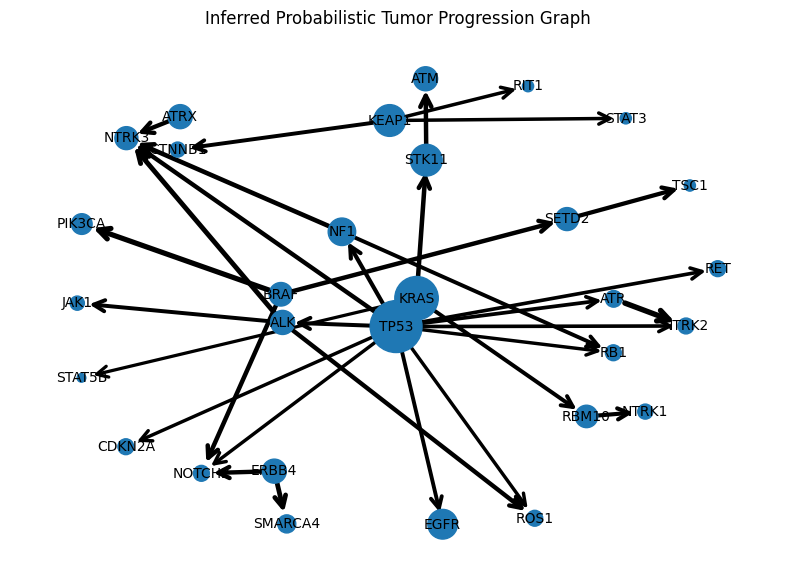

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

pos = nx.spring_layout(G_prog, seed=42)

node_sizes = [
    3000 * prevalence.get(node, 0.05)
    for node in G_prog.nodes()
]

edge_widths = [
    2 + 8 * G_prog[u][v]["weight"]
    for u, v in G_prog.edges()
]

nx.draw_networkx_nodes(
    G_prog,
    pos,
    node_size=node_sizes
)

nx.draw_networkx_edges(
    G_prog,
    pos,
    width=edge_widths,
    arrows=True,
    arrowsize=20,
    arrowstyle="->"
)

nx.draw_networkx_labels(
    G_prog,
    pos,
    font_size=10
)

plt.title("Inferred Probabilistic Tumor Progression Graph")
plt.axis("off")
plt.show()

In [10]:
for u, v, data in G_prog.edges(data=True):
    if u == "KRAS" or v == "KRAS" or u == "STK11" or v == "STK11" or u == "KEAP1" or v == "KEAP1":
        print(
            f"{u} → {v} | "
            f"Gain={data['weight']:.3f}, "
            f"OR={data['odds_ratio']:.2f}, "
            f"p={data['p_value']:.4f}, "
            f"CoOcc={data['cooccurrence']}"
        )

KRAS → STK11 | Gain=0.157, OR=2.78, p=0.0050, CoOcc=21
KRAS → RBM10 | Gain=0.108, OR=3.50, p=0.0108, CoOcc=12
KRAS → STAT5B | Gain=0.040, OR=inf, p=0.0337, CoOcc=3
STK11 → ATM | Gain=0.151, OR=3.65, p=0.0077, CoOcc=9
KEAP1 → CTNNB1 | Gain=0.104, OR=6.64, p=0.0093, CoOcc=5
KEAP1 → STAT3 | Gain=0.064, OR=7.62, p=0.0381, CoOcc=3
KEAP1 → RIT1 | Gain=0.064, OR=7.62, p=0.0381, CoOcc=3


In [11]:
OUTPUT_DIR = f"{DATA_DIR}/Results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

progression_df.to_csv(
    f"{OUTPUT_DIR}/notebook07_all_progression_tests.csv",
    index=False
)

progression_edges.to_csv(
    f"{OUTPUT_DIR}/notebook07_inferred_progression_edges.csv",
    index=False
)

nx.write_graphml(
    G_prog,
    f"{OUTPUT_DIR}/notebook07_progression_graph.graphml"
)

print("Saved Notebook 07 outputs.")

Saved Notebook 07 outputs.
